(('II', 'IX'), (1, -1))
<IPython.core.display.Latex object>
(('II', 'XI'), (1, -1))
<IPython.core.display.Latex object>
(('II', 'XX'), (1, -1))
<IPython.core.display.Latex object>
(('II', 'IX', 'XI'), (2, -1, -1))
<IPython.core.display.Latex object>
(('II', 'IX', 'XX'), (2, -1, -1))
<IPython.core.display.Latex object>
(('II', 'XI', 'XX'), (2, -1, -1))
<IPython.core.display.Latex object>
(('II', 'IX', 'XI', 'XX'), (3, -1, -1, -1))
<IPython.core.display.Latex object>


/tmp/ipykernel_20009/833010306.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  L_dense = L_sparse.to_matrix().astype(np.float64)


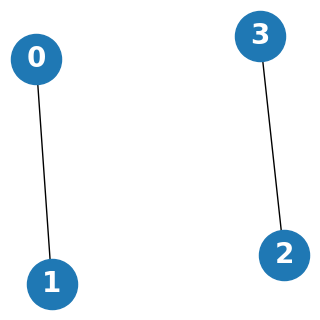

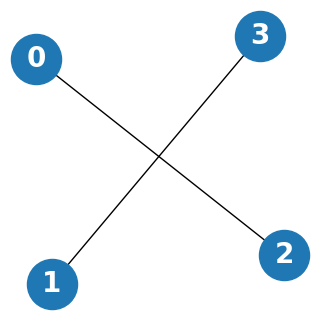

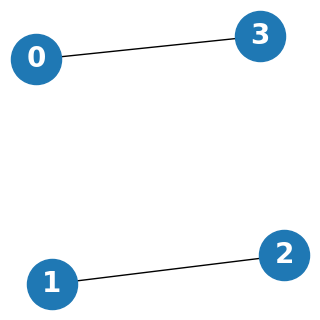

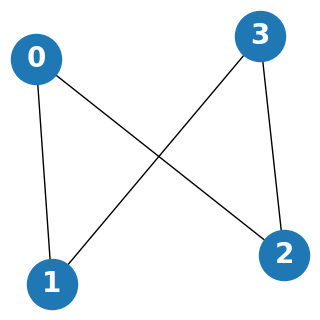

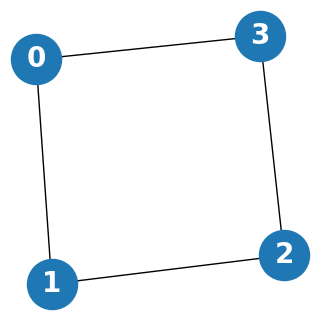

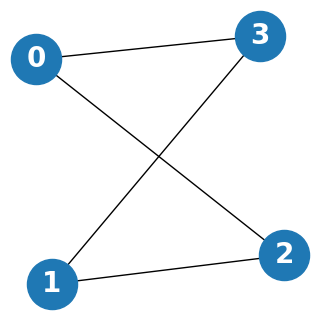

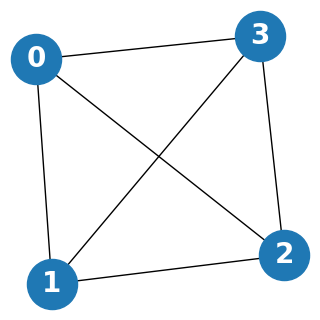

In [74]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp

from qsga.util import decompose_laplacian_matrix


combinations_IX_2 = [
    (("II", "IX"), (1, -1)),
    (("II", "XI"), (1, -1)),
    (("II", "XX"), (1, -1)),
    (("II", "IX", "XI"), (2, -1, -1)),
    (("II", "IX", "XX"), (2, -1, -1)),
    (("II", "XI", "XX"), (2, -1, -1)),
    (("II", "IX", "XI", "XX"), (3, -1, -1, -1)),
]
num_options = len(combinations_IX_2)

dense_laplacians = []
for index, combination in enumerate(combinations_IX_2):
    L_sparse = SparsePauliOp(data=combination[0], coeffs=combination[1])
    L_dense = L_sparse.to_matrix().astype(np.float64)
    
    dense_laplacians.append(L_dense)
    
    diagonal, D, A = decompose_laplacian_matrix(L_dense)
    graph = nx.from_numpy_array(A)
    
    plt.figure(figsize=(3, 3))
    
    if index == 0:
        pos = nx.spring_layout(graph, k=2)
        
    nx.draw(
        graph,
        pos,
        with_labels=True,
        node_size=1_300,
        font_size=20,
        font_weight="bold",
        font_color="white"
    )
    
    plt.savefig(f"graph_{index + 1}.png", dpi=200, bbox_inches="tight")
    
    print(combination)